In [36]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import optuna
import json
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report, 
    roc_auc_score, 
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import shap
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances
)
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv('matching_dataset_final.csv')

gss = GroupShuffleSplit(
    test_size=0.2,
    random_state=42
)

train_idx, temp_idx = next(
    gss.split(
        df,
        groups=df["driver_id"]
    )
)

train_df = df.iloc[train_idx]
temp_df = df.iloc[temp_idx]

# temp -> valid/test

gss2 = GroupShuffleSplit(
    test_size=0.5,
    random_state=42
)

valid_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["driver_id"]
    )
)

valid_df = temp_df.iloc[valid_idx]
test_df = temp_df.iloc[test_idx]

print("--- สรุปจำนวนข้อมูล (Rows) ---")
print(f"จำนวนข้อมูล Train: {len(train_df):,} แถว")
print(f"จำนวนข้อมูล Valid: {len(valid_df):,} แถว")
print(f"จำนวนข้อมูล Test: {len(test_df):,} แถว")
print(f"จำนวนข้อมูลทั้งหมดก่อน Split: {len(df):,} แถว")

print("\n--- สรุปจำนวน Driver ID (Groups) ---")
print(f"จำนวน Driver ใน Train: {train_df['driver_id'].nunique():,} คน")
print(f"จำนวน Driver ใน Valid: {valid_df['driver_id'].nunique():,} คน")
print(f"จำนวน Driver ใน Test: {test_df['driver_id'].nunique():,} คน")
print(f"จำนวน Driver ทั้งหมด: {df['driver_id'].nunique():,} คน")

print("\n--- ตัวอย่างข้อมูล Train Data (5 แถว) ---")
display(train_df.head(5))

print("\n--- ตัวอย่างข้อมูล Validation Data (5 แถว) ---")
display(valid_df.head(5))

print("\n--- ตัวอย่างข้อมูล Test Data (5 แถว) ---")
display(test_df.head(5))

--- สรุปจำนวนข้อมูล (Rows) ---
จำนวนข้อมูล Train: 80,062 แถว
จำนวนข้อมูล Valid: 9,887 แถว
จำนวนข้อมูล Test: 10,051 แถว
จำนวนข้อมูลทั้งหมดก่อน Split: 100,000 แถว

--- สรุปจำนวน Driver ID (Groups) ---
จำนวน Driver ใน Train: 400 คน
จำนวน Driver ใน Valid: 50 คน
จำนวน Driver ใน Test: 50 คน
จำนวน Driver ทั้งหมด: 500 คน

--- ตัวอย่างข้อมูล Train Data (5 แถว) ---


,driver_id,historical_accept_rate,historical_cancel_rate,historical_framework_preference,matched_framework,framework_match,has_rejected_this_job,fatigue_level,earnings_today,idle_time_minutes,...,pickup_detour_km,total_detour_km,eta_delay_minutes,estimated_fuel_cost,expected_margin,margin_per_km,nearby_driver_count,marketplace_job_density,supply_demand_ratio,accepted
1,D0291,0.4229,0.1187,5,4,0,0,5.41,1092.92,5.24,...,8.65,11.36,28.19,43.69,566.14,28.66,19,16,1.188,1
2,D0125,0.6767,0.0254,4,2,0,0,1.10,3389.71,77.64,...,6.96,26.47,83.41,88.90,2893.82,31.47,12,9,1.333,1
3,D0332,0.4508,0.1402,5,1,0,0,4.12,912.24,19.88,...,9.58,10.81,30.42,30.13,1847.46,26.92,18,12,1.500,0
4,D0216,0.5655,0.0873,1,4,0,1,7.96,5541.04,20.77,...,5.49,18.16,60.52,81.32,959.08,38.52,11,12,0.917,0
6,D0434,0.9153,0.0624,5,5,1,0,7.50,1853.29,36.59,...,10.37,14.69,34.27,38.53,1346.16,16.60,15,17,0.882,1



--- ตัวอย่างข้อมูล Validation Data (5 แถว) ---


,driver_id,historical_accept_rate,historical_cancel_rate,historical_framework_preference,matched_framework,framework_match,has_rejected_this_job,fatigue_level,earnings_today,idle_time_minutes,...,pickup_detour_km,total_detour_km,eta_delay_minutes,estimated_fuel_cost,expected_margin,margin_per_km,nearby_driver_count,marketplace_job_density,supply_demand_ratio,accepted
9,D0084,0.7292,0.1755,1,4,0,1,5.61,1581.50,14.06,...,2.43,6.37,13.07,22.98,896.37,20.82,11,17,0.647,0
15,D0209,0.9800,0.0687,4,3,0,0,4.68,3181.86,29.24,...,4.47,13.04,44.48,51.96,874.54,21.66,17,17,1.000,1
20,D0451,0.7223,0.0992,5,1,0,0,1.34,990.27,60.54,...,3.61,11.76,41.76,37.46,1563.16,29.35,16,13,1.231,1
34,D0485,0.5883,0.1828,5,2,0,0,1.99,1771.53,93.92,...,5.40,12.63,33.17,33.12,1050.03,15.65,17,11,1.545,1
60,D0410,0.3004,0.1307,1,2,0,0,6.76,1536.88,31.88,...,6.41,22.49,81.31,87.39,625.03,27.79,16,11,1.455,0



--- ตัวอย่างข้อมูล Test Data (5 แถว) ---


,driver_id,historical_accept_rate,historical_cancel_rate,historical_framework_preference,matched_framework,framework_match,has_rejected_this_job,fatigue_level,earnings_today,idle_time_minutes,...,pickup_detour_km,total_detour_km,eta_delay_minutes,estimated_fuel_cost,expected_margin,margin_per_km,nearby_driver_count,marketplace_job_density,supply_demand_ratio,accepted
0,D0374,0.6632,0.1309,4,1,0,0,2.28,940.72,15.65,...,11.92,13.65,38.51,38.58,790.45,47.98,11,9,1.222,1
5,D0015,0.6009,0.0032,2,4,0,0,4.25,1624.16,4.74,...,4.69,5.51,13.51,19.84,3056.44,36.14,15,10,1.500,0
14,D0072,0.4848,0.1415,1,1,1,0,0.91,2195.03,65.81,...,8.90,15.81,56.76,49.76,974.76,17.53,18,14,1.286,0
31,D0377,0.5782,0.0462,2,1,0,0,6.38,1571.87,70.16,...,4.07,8.33,22.23,30.33,15.68,14.87,21,6,3.500,1
35,D0438,0.7801,0.1782,4,3,0,0,5.71,3463.47,88.03,...,2.17,6.34,15.95,21.74,1898.77,36.39,20,7,2.857,1


In [39]:
cat_features = [
    "historical_framework_preference",
    "matched_framework"
]

X_train = train_df.drop(
    columns=[
        "accepted",
        "driver_id"
    ]
)
y_train = train_df["accepted"]

X_valid = valid_df.drop(
    columns=[
        "accepted",
        "driver_id"
    ]
)
y_valid = valid_df["accepted"]

X_test = test_df.drop(
    columns=[
        "accepted",
        "driver_id"
    ]
)
y_test = test_df["accepted"]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}\n")

print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}\n")

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# print("--- ตัวอย่างข้อมูล X_train (5 แถวแรก) ---")
# display(X_train.head())

# print("\n--- ตัวอย่างข้อมูล y_train (5 แถวแรก) ---")
# display(y_train.head())

print("\n--- ข้อมูล Data Types และ Missing Values ใน X_train ---")
summary_df = pd.DataFrame({
    'Data Type': X_train.dtypes,
    'Missing Values': X_train.isnull().sum(),
    '% Missing': (X_train.isnull().sum() / len(X_train)) * 100
})
display(summary_df)

print("\n--- สัดส่วนของคลาสใน y_train (Class Distribution) ---")
target_counts = y_train.value_counts()
target_percents = y_train.value_counts(normalize=True) * 100
target_summary = pd.DataFrame({
    'Count': target_counts, 
    'Percentage (%)': target_percents
})
display(target_summary)

print("\n--- ตรวจสอบ Categorical Features ---")
for col in cat_features:
    if col in X_train.columns:
        unique_vals = X_train[col].nunique()
        print(f"Feature '{col}' มีค่าที่ไม่ซ้ำกันทั้งหมด {unique_vals} ค่า")
    else:
        print(f"ไม่พบ Feature '{col}' ใน X_train!")

# print(set(train_df["driver_id"]) & set(valid_df["driver_id"]))
# print(set(train_df["driver_id"]) & set(test_df["driver_id"]))
# print(set(valid_df["driver_id"]) & set(test_df["driver_id"]))

X_train shape: (80062, 23)
y_train shape: (80062,)

X_valid shape: (9887, 23)
y_valid shape: (9887,)

X_test shape: (10051, 23)
y_test shape: (10051,)


--- ข้อมูล Data Types และ Missing Values ใน X_train ---


,Data Type,Missing Values,% Missing
historical_accept_rate,float64,0,0.0
historical_cancel_rate,float64,0,0.0
historical_framework_preference,int64,0,0.0
matched_framework,int64,0,0.0
framework_match,int64,0,0.0
has_rejected_this_job,int64,0,0.0
fatigue_level,float64,0,0.0
earnings_today,float64,0,0.0
idle_time_minutes,float64,0,0.0
hour_of_day,int64,0,0.0



--- สัดส่วนของคลาสใน y_train (Class Distribution) ---


,Count,Percentage (%)
accepted,,
1,41237,51.506333
0,38825,48.493667



--- ตรวจสอบ Categorical Features ---
Feature 'historical_framework_preference' มีค่าที่ไม่ซ้ำกันทั้งหมด 5 ค่า
Feature 'matched_framework' มีค่าที่ไม่ซ้ำกันทั้งหมด 5 ค่า


In [41]:
def objective(trial):
    params = {
        "iterations": 3000, 
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "depth": trial.suggest_int("depth", 5, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 10, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 3),
        "border_count": trial.suggest_int("border_count", 64, 255),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50),

        "loss_function": "Logloss",
        "eval_metric": "AUC", 
        
        "random_seed": 42,
        "verbose": False
    }

    model = CatBoostClassifier(**params)

    model.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=100, 
        verbose=False
    )

    prob = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, prob)
    
    return auc

pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=50)
study = optuna.create_study(direction="maximize", study_name="catboost_matching", pruner=pruner)

print("start hyperparameter search with optuna ..")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\n--- search completed ---")
print(f"best AUC on valid data : {study.best_value:.4f}")
print("best hyperparameter :")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

[I 2026-06-23 16:24:25,546] A new study created in memory with name: catboost_matching


start hyperparameter search with optuna ..


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-23 16:25:42,007] Trial 0 finished with value: 0.7507973380391095 and parameters: {'learning_rate': 0.012296788270212857, 'depth': 7, 'l2_leaf_reg': 4.668369185526207, 'random_strength': 7.708742206252877, 'bagging_temperature': 0.6939925937725485, 'border_count': 139, 'min_data_in_leaf': 18}. Best is trial 0 with value: 0.7507973380391095.
[I 2026-06-23 16:26:05,213] Trial 1 finished with value: 0.750677357140954 and parameters: {'learning_rate': 0.037616427228775215, 'depth': 7, 'l2_leaf_reg': 15.860205887230158, 'random_strength': 0.22338633081521989, 'bagging_temperature': 2.0089147797817715, 'border_count': 243, 'min_data_in_leaf': 12}. Best is trial 0 with value: 0.7507973380391095.
[I 2026-06-23 16:28:05,906] Trial 2 finished with value: 0.7513082918811013 and parameters: {'learning_rate': 0.005619091592119163, 'depth': 6, 'l2_leaf_reg': 3.1024891562221053, 'random_strength': 2.61980738546934, 'bagging_temperature': 0.016782193820772395, 'border_count': 206, 'min_data_

In [42]:
train_final_df = pd.concat([train_df, valid_df])
X_train_final = train_final_df.drop(
    columns=[
        "accepted",
        "driver_id"
    ]
)
y_train_final = train_final_df["accepted"]

In [43]:
# final_model = CatBoostClassifier(
#     iterations=3000,
#     learning_rate=0.010138495573373998,
#     depth=7,
#     l2_leaf_reg=4.148105399147567,
#     random_strength=2.447545350613807,
#     bagging_temperature=2.1214184492147896,
#     border_count=203,
#     min_data_in_leaf=31,

#     loss_function="Logloss",
#     eval_metric="AUC",
#     random_seed=42,
#     verbose=100
# )

final_model = CatBoostClassifier(
    iterations=3000,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    **study.best_params
)

final_model.fit(
    X_train_final,
    y_train_final,
    cat_features=cat_features,
    verbose=100
)

final_model.save_model("marketplace_matching.cbm")

with open("best_params.json", "w") as f:
    json.dump(study.best_params, f, indent=4)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:,1]

0:	total: 43.7ms	remaining: 2m 11s
100:	total: 4.92s	remaining: 2m 21s
200:	total: 9.61s	remaining: 2m 13s
300:	total: 14.2s	remaining: 2m 7s
400:	total: 18.9s	remaining: 2m 2s
500:	total: 23.6s	remaining: 1m 57s
600:	total: 28.3s	remaining: 1m 52s
700:	total: 33s	remaining: 1m 48s
800:	total: 37.6s	remaining: 1m 43s
900:	total: 42.1s	remaining: 1m 38s
1000:	total: 46.8s	remaining: 1m 33s
1100:	total: 51.5s	remaining: 1m 28s
1200:	total: 56.6s	remaining: 1m 24s
1300:	total: 1m 1s	remaining: 1m 20s
1400:	total: 1m 6s	remaining: 1m 15s
1500:	total: 1m 10s	remaining: 1m 10s
1600:	total: 1m 15s	remaining: 1m 6s
1700:	total: 1m 20s	remaining: 1m 1s
1800:	total: 1m 25s	remaining: 56.8s
1900:	total: 1m 30s	remaining: 52.2s
2000:	total: 1m 35s	remaining: 47.5s
2100:	total: 1m 40s	remaining: 42.8s
2200:	total: 1m 44s	remaining: 38.1s
2300:	total: 1m 49s	remaining: 33.4s
2400:	total: 1m 54s	remaining: 28.6s
2500:	total: 1m 59s	remaining: 23.9s
2600:	total: 2m 4s	remaining: 19.1s
2700:	total: 2m 

In [44]:
metrics = pd.DataFrame([{
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
    "log_loss": log_loss(y_test, y_prob)
}])
display(metrics)

metrics.to_csv("metrics.csv", index=False)

,accuracy,precision,recall,f1,roc_auc,log_loss
0,0.677346,0.685648,0.688962,0.687301,0.747992,0.590545


In [45]:
train_prob = final_model.predict_proba(X_train_final)[:,1]

metrics = pd.DataFrame([{
    "train_roc_auc": roc_auc_score(y_train_final, train_prob),
}])
display(metrics)

,train_roc_auc
0,0.816157


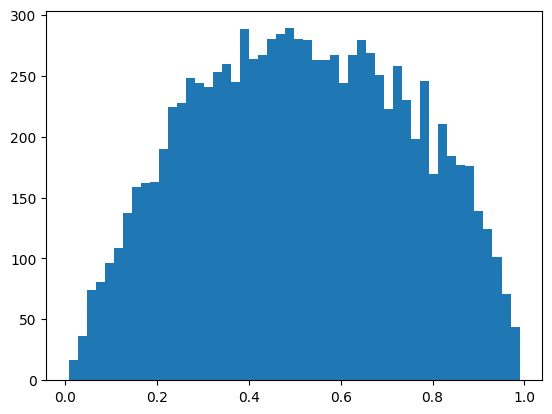

In [47]:
plt.hist(y_prob, bins=50)
plt.show()

In [48]:
report = classification_report(y_test, y_pred, output_dict=True)
display(pd.DataFrame(report).T)

report_df = pd.DataFrame(report).T
report_df.to_csv("classification_report.csv")

,precision,recall,f1-score,support
0,0.668453,0.665027,0.666735,4878.000000
1,0.685648,0.688962,0.687301,5173.000000
accuracy,0.677346,0.677346,0.677346,0.677346
macro avg,0.677050,0.676994,0.677018,10051.000000
weighted avg,0.677303,0.677346,0.677320,10051.000000


In [49]:
optuna_results = study.trials_dataframe()
optuna_results.to_csv("optuna_trials.csv", index=False)
display(optuna_results.sort_values("value", ascending=False).head(10))

fig1 = plot_optimization_history(study)
fig2 = plot_param_importances(study)
fig1.show()
fig2.show()

,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_border_count,params_depth,params_l2_leaf_reg,params_learning_rate,params_min_data_in_leaf,params_random_strength,state
53,53,0.752074,2026-06-23 17:03:57.519953,2026-06-23 17:04:22.683413,0 days 00:00:25.163460,2.885399,231,5,13.616062,0.031145,48,2.624851,COMPLETE
61,61,0.752012,2026-06-23 17:07:49.154655,2026-06-23 17:08:15.452537,0 days 00:00:26.297882,0.845938,214,5,6.184408,0.029729,50,2.523406,COMPLETE
87,87,0.751856,2026-06-23 17:43:04.352232,2026-06-23 17:44:26.197974,0 days 00:01:21.845742,1.631440,174,6,12.879755,0.010805,44,6.006561,COMPLETE
73,73,0.751855,2026-06-23 17:18:03.070530,2026-06-23 17:20:03.050632,0 days 00:01:59.980102,0.810470,173,5,3.580319,0.007587,44,2.507771,COMPLETE
94,94,0.751842,2026-06-23 17:54:22.816120,2026-06-23 17:55:30.119929,0 days 00:01:07.303809,1.110125,169,6,8.977726,0.011616,47,2.921814,COMPLETE
84,84,0.751804,2026-06-23 17:39:06.376985,2026-06-23 17:40:19.516056,0 days 00:01:13.139071,1.621416,182,6,12.720479,0.009756,50,2.746716,COMPLETE
79,79,0.751747,2026-06-23 17:27:48.305168,2026-06-23 17:30:01.419444,0 days 00:02:13.114276,1.310965,191,7,11.638207,0.007978,48,2.292154,COMPLETE
97,97,0.751742,2026-06-23 17:57:50.086002,2026-06-23 17:58:10.094133,0 days 00:00:20.008131,1.379124,172,6,12.703247,0.049867,50,2.147132,COMPLETE
59,59,0.751725,2026-06-23 17:07:12.262933,2026-06-23 17:07:28.872199,0 days 00:00:16.609266,0.813661,220,5,2.559049,0.035403,50,0.899770,COMPLETE
92,92,0.751708,2026-06-23 17:51:47.228126,2026-06-23 17:53:00.693922,0 days 00:01:13.465796,1.469687,177,6,12.724816,0.009427,47,3.134463,COMPLETE


In [50]:
importance = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": final_model.get_feature_importance()
})

display(
    importance.sort_values(
        "importance",
        ascending=False
    )
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

,feature,importance
18,expected_margin,18.402823
0,historical_accept_rate,12.307593
1,historical_cancel_rate,11.480066
6,fatigue_level,5.793539
5,has_rejected_this_job,5.395870
14,pickup_detour_km,4.901962
16,eta_delay_minutes,4.159369
19,margin_per_km,3.776563
4,framework_match,3.675338
10,current_load_utilization,3.484149


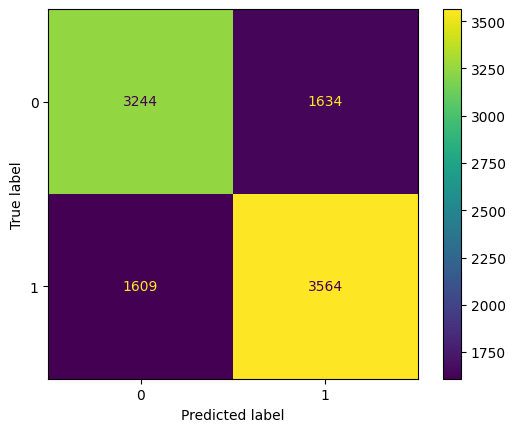

In [51]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [52]:
framework_stats = (df.groupby("matched_framework")["accepted"].mean().reset_index())
display(framework_stats)

,matched_framework,accepted
0,1,0.523637
1,2,0.525631
2,3,0.506425
3,4,0.513434
4,5,0.496705


In [53]:
df["detour_bucket"] = pd.cut(df["total_detour_km"], bins=[0,5,10,20,50])
display(df.groupby("detour_bucket")["accepted"].mean())

C:\Users\USER\AppData\Local\Temp\ipykernel_23436\1814764187.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby("detour_bucket")["accepted"].mean())


detour_bucket
(0, 5]      0.627226
(5, 10]     0.582898
(10, 20]    0.506638
(20, 50]    0.405073
Name: accepted, dtype: float64

In [54]:
df["margin_bucket"] = pd.qcut(df["expected_margin"], 5)
display(df.groupby("margin_bucket")["accepted"].mean())

C:\Users\USER\AppData\Local\Temp\ipykernel_23436\361176800.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby("margin_bucket")["accepted"].mean())


margin_bucket
(-153.371, 400.038]     0.320100
(400.038, 691.07]       0.406030
(691.07, 1049.548]      0.488274
(1049.548, 1625.524]    0.598300
(1625.524, 9882.37]     0.765300
Name: accepted, dtype: float64

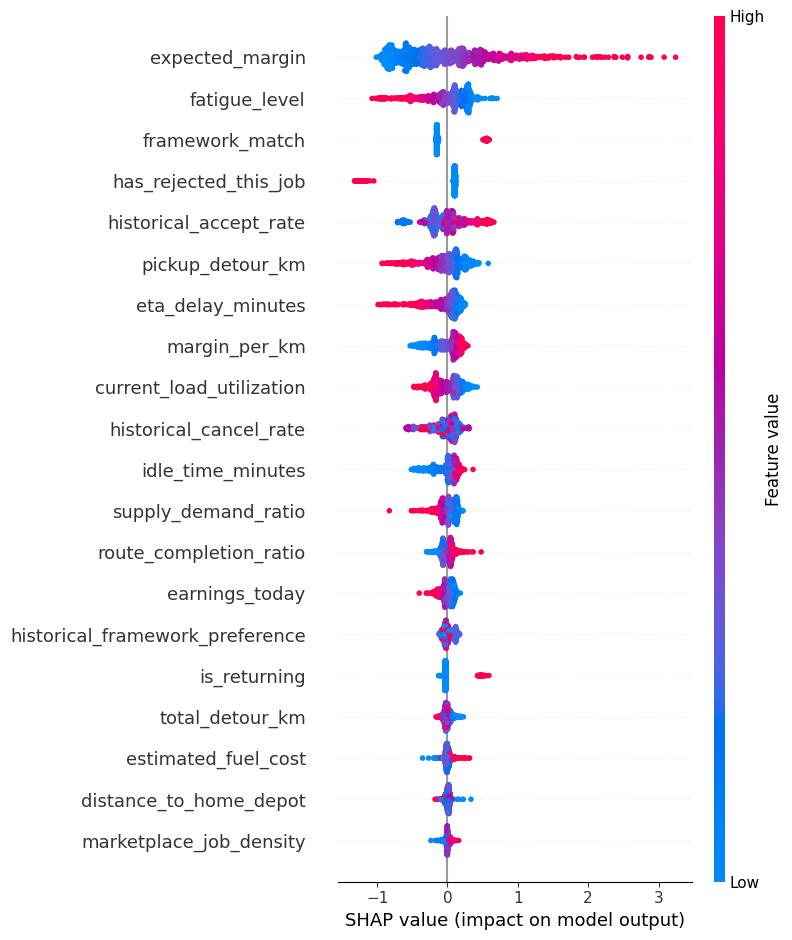

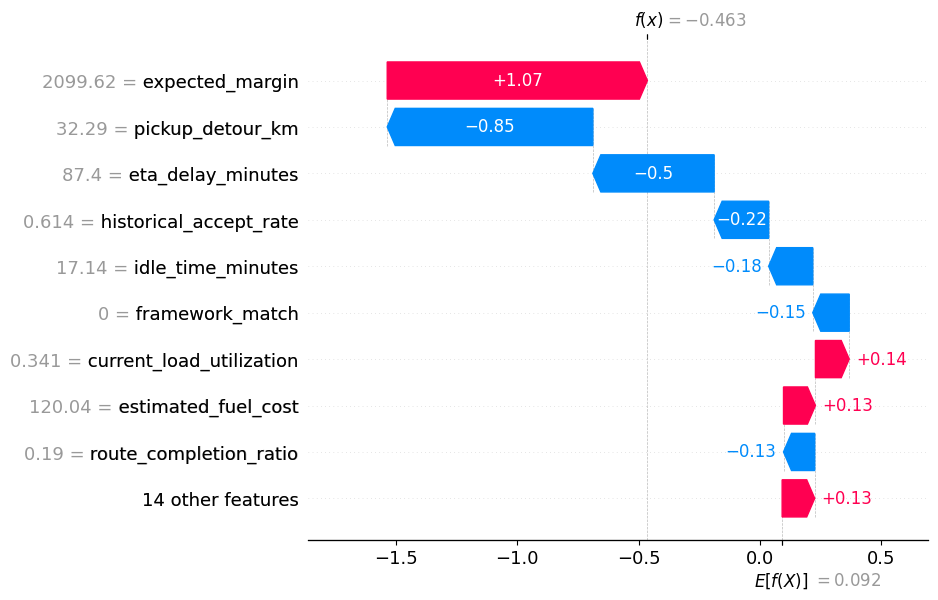

In [55]:
explainer = shap.TreeExplainer(final_model)
sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=sample.columns
    )
)

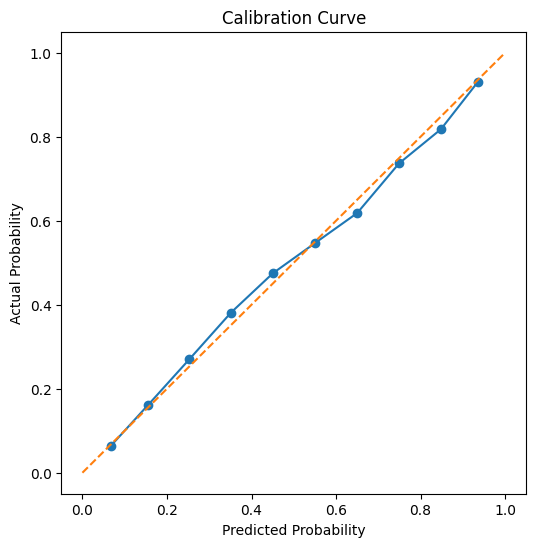

In [56]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], "--")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve")
plt.show()